# Allen-Cahn PDE

## Domain Incremental Learning - Dom0

### Experiments nomenclature

`L`[learning_mode]

- learning_mode $\in$ \{$w_1+...+w_k$ | \{$w_1, ..., w_k$\} $\in \mathcal{P}$(\{`pinn`, `out`, `der`, `hes`\})\}

### Experiments location

**AllenCahn**

- **Dom0**
    - **models0** | ... | **modelsM**
        - **tiral0** | ... | **trialN**
            - model.pth, training stats files

In [1]:
import torch
from torch.utils.data import TensorDataset, ConcatDataset
from data_utils import compute_prediction_difference, compute_prediction, extract_targets
from plot_utils import plot_loss_comp, plot_model_stats, print_model_info, plot_points_grid, plot_model_stats_grid, print_model_performances, plot_model_performances, plot_performance_comparison
from load_store_utils import load_stats, resume_model
from train import start_train
from typing import List
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
# -------------------
TRAIN = True
SAVE_PLOTS = True
CROSS_THE_RUBICON = True

PDE = "AllenCahn"
PDE_NAME = "Allen-Cahn"
SEED = 42
PARAM_INDEX = None
ACTUAL_MODE = "PINN"
DOM = 0
N_EPOCHS = 10

LR_MODE = "CosAnn"
BD_MODE = "LocalFull" #LocalFull Local Global
DWA_MODE = "Norm1"
CLIP_GRAD = True
# ----------------------------------------------
if LR_MODE == "ExpDec":
    LR = "_ExpLrDecay"
else:
    LR_MODE = "CosAnn"
    LR = "_CosLrAnnealing"

if PARAM_INDEX is None:
    DIR = "MultiTask"
    BATCH_SIZE_TRAIN = 1024
    BATCH_SIZE_DEV = 1024
else:
    DIR = f"Task{PARAM_INDEX}"
    BATCH_SIZE_TRAIN = 512
    BATCH_SIZE_DEV = 512
    
if not CLIP_GRAD:
    CLIP = "NoGradClip"
else:
    CLIP = "GradClip"

/home/claudia/tesi/ANN_fisica/code/code/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Functions to work with the A-C dataset

In [2]:
def merge_ds(datasets: List[TensorDataset]) -> TensorDataset:
    cols = None   
    for ds in datasets:
        new_cols = list(ds.tensors)
        if cols is None:
            cols = new_cols
        else:
            for i, col in enumerate(new_cols):
                cols[i] = torch.cat([cols[i], col])
    return TensorDataset(*cols)

def prepare_dataset(datasets: List[ConcatDataset]) -> ConcatDataset:
    n_snapshots = len(datasets[0].datasets)
    data = [None for _ in range(n_snapshots)]
    for i in range(n_snapshots):
        data[i] = merge_ds([concat_ds.datasets[i] for concat_ds in datasets])
    return ConcatDataset(data)

### Load datasets

In [3]:
full_datasets = torch.load(f"{PDE}/data/full_datasets.pth", weights_only=False).datasets
unlabeled_datasets = torch.load(f"{PDE}/data/unlabeled_datasets.pth", weights_only=False).datasets
dev_datasets = torch.load(f"{PDE}/data/dev_datasets.pth", weights_only=False).datasets
train_datasets = torch.load(f"{PDE}/data/train_datasets.pth", weights_only=False).datasets
val_datasets = torch.load(f"{PDE}/data/val_datasets.pth", weights_only=False).datasets
inter_test_datasets = torch.load(f"{PDE}/data/inter_test_datasets.pth", weights_only=False).datasets
intra_test_datasets = torch.load(f"{PDE}/data/intra_test_datasets.pth", weights_only=False).datasets

n_params = 2 # number of xi_j

subsets = [
    {"x": [0.0, 1.0], "y": [0.0, 1.0]},
    {"x": [0.0, 1.0], "y": [-1.0, 0.0]},
    {"x": [-1.0, 0.0], "y": [-1.0, 0.0]},
    {"x": [-1.0, 0.0], "y": [0.0, 1.0]}
]

if PARAM_INDEX != None:
    train_dataset = [train_datasets[PARAM_INDEX]]
    val_dataset = [val_datasets[PARAM_INDEX]]
    dev_dataset = [dev_datasets[PARAM_INDEX]]
    intra_test_dataset = [intra_test_datasets[PARAM_INDEX]]
else:
    train_dataset = train_datasets
    val_dataset = val_datasets
    dev_dataset = dev_datasets
    intra_test_dataset = intra_test_datasets

train_data = prepare_dataset(train_dataset)
val_data = prepare_dataset(val_dataset)
dev_data = prepare_dataset(dev_dataset)
intra_test_data = prepare_dataset(intra_test_dataset)

In [4]:
print(len(dev_data))
print(len(train_data))

32768
24576


### Task 0

#### 1st model selection step
Perform 20 trials of 10 epochs each.

In [5]:
if TRAIN:
    models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models0"

    actual = {
        "mode": ACTUAL_MODE,
        "time_in_input": False,
        "space_in_input": True,
        "fourier_features": [-1, 5, 10, 20, 30],
        "pde_params_in_input": [f"xi{i+1}" for i in range(n_params)],
        "boundary": BD_MODE,
        "monitor_conflicts": True,
        #"bc_importance": [0.01, 0.05, 0.1, 0.5, 1.0],
        "train_dataset": train_data,
        "val_dataset": val_data,
        "subset": subsets[DOM]
    }
    distill = {
        "mode": "Forgetting",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    ewc = {
        "mode": "Off",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    dwa = {
        "mode": DWA_MODE,
        "moving_avg_factor": 0.9,
        "moving_avg_frequency": 1,
        "warm_up": 3
    }
    config_dict = {
        "PDE": PDE_NAME,
        "Actual": actual,
        "Distillation": distill,
        "EWC": ewc,
        "DWA": dwa,
        "pruner": "median",
        "n_warmup_steps": 3,
        "threshold": 1.0,
        "n_trials": 10,
        "epochs": 10,
        "eval_every": 1,
        "seed": SEED,
        "device": "cpu",
        "learning_rate": [1e-2, 1e-3],
        "scheduler": LR_MODE,
        "clip_grad": CLIP_GRAD,
        "batch_size": min(BATCH_SIZE_TRAIN, len(train_data)),
        "models_dir": models_dir,
        "suggestions": "On"
    }
    start_train(config_dict)

[I 2026-02-26 19:15:07,093] A new study created in memory with name: no-name-3f4984ae-9663-4e09-ae30-97d57f243d51


batch_size_train = 1024
len(train_dataset) = 6144
batch_size_val = 1024
len(val_dataset) = 1024
batch_size_train_bc = 508
len(train_bc_dataset) = 508
batch_size_val_bc = 160
len(val_bc_dataset) = 160

Epoch: 0, step_prefix: 0
Epoch time: 1.0022392272949219
train weighted loss: 0.012729393939177195
train out loss: 0.011707407888025045
val weighted loss: 0.01644478365778923
val out loss: 0.01627851091325283

Epoch: 1, step_prefix: 6
Epoch time: 0.752638578414917
train weighted loss: 0.00961675945048531
train out loss: 0.010332612631221613
val weighted loss: 0.012521157041192055
val out loss: 0.014898695051670074

Epoch: 2, step_prefix: 12
Epoch time: 0.7727837562561035
train weighted loss: 0.0071265654017527895
train out loss: 0.009137604385614395
val weighted loss: 0.009149845689535141
val out loss: 0.013512295670807362

Epoch: 3, step_prefix: 18
Epoch time: 0.7217366695404053
train weighted loss: 0.008705108892172575
train out loss: 0.010073888736466566
val weighted loss: 0.01161635294

[I 2026-02-26 19:15:21,715] Trial 0 finished with value: 0.023565529845654964 and parameters: {'lr_init': 0.001, 'fourier_features': -1}. Best is trial 0 with value: 0.023565529845654964.


val weighted loss: 0.011035108007490635
val out loss: 0.014211463741958141
batch_size_train = 1024
len(train_dataset) = 6144
batch_size_val = 1024
len(val_dataset) = 1024
batch_size_train_bc = 508
len(train_bc_dataset) = 508
batch_size_val_bc = 160
len(val_bc_dataset) = 160

Epoch: 0, step_prefix: 0
Epoch time: 0.6731653213500977
train weighted loss: 0.011038462941845259
train out loss: 0.017147105497618515
val weighted loss: 0.01334740687161684
val out loss: 0.024161307141184807

Epoch: 1, step_prefix: 6
Epoch time: 0.5778305530548096
train weighted loss: 0.009996843834718069
train out loss: 0.014071242262919744
val weighted loss: 0.013129668310284615
val out loss: 0.02002396434545517

Epoch: 2, step_prefix: 12
Epoch time: 0.8042364120483398
train weighted loss: 0.009145062261571487
train out loss: 0.011071514338254929
val weighted loss: 0.012735774740576744
val out loss: 0.016702309250831604

Epoch: 3, step_prefix: 18
Epoch time: 0.7861018180847168
train weighted loss: 0.007868559720

[I 2026-02-26 19:15:35,378] Trial 1 finished with value: 0.018851819215342402 and parameters: {'lr_init': 0.01, 'fourier_features': 10}. Best is trial 1 with value: 0.018851819215342402.


...

train weighted loss: 0.0044157894638677435
train out loss: 0.011798680449525515
val weighted loss: 0.005966487340629101
val out loss: 0.017621908336877823
batch_size_train = 1024
len(train_dataset) = 6144
batch_size_val = 1024
len(val_dataset) = 1024
batch_size_train_bc = 508
len(train_bc_dataset) = 508
batch_size_val_bc = 160
len(val_bc_dataset) = 160

Epoch: 0, step_prefix: 0
Epoch time: 0.5745911598205566
train weighted loss: 0.006981929220880072
train out loss: 0.016276829255123932
val weighted loss: 0.009608539752662182
val out loss: 0.024312248453497887

Epoch: 1, step_prefix: 6
Epoch time: 0.6718244552612305
train weighted loss: 0.008286157778153816
train out loss: 0.014207010778288046
val weighted loss: 0.011309614405035973
val out loss: 0.02070297673344612

Epoch: 2, step_prefix: 12
Epoch time: 0.791672945022583
train weighted loss: 0.01168994108835856
train out loss: 0.013358331751078367
val weighted loss: 0.01614563912153244
val out loss: 0.019661705940961838

Epoch: 3, step

[I 2026-02-26 19:16:44,207] Trial 8 pruned. 


train weighted loss: 0.004796569313233097
train out loss: 0.012727769246945778
val weighted loss: 0.006622861139476299
val out loss: 0.018919024616479874
batch_size_train = 1024
len(train_dataset) = 6144
batch_size_val = 1024
len(val_dataset) = 1024
batch_size_train_bc = 508
len(train_bc_dataset) = 508
batch_size_val_bc = 160
len(val_bc_dataset) = 160

Epoch: 0, step_prefix: 0
Epoch time: 0.7891886234283447
train weighted loss: 0.010947950650006533
train out loss: 0.017323384682337444
val weighted loss: 0.014541015960276127
val out loss: 0.02533823251724243

Epoch: 1, step_prefix: 6
Epoch time: 0.5657989978790283
train weighted loss: 0.008363457086185614
train out loss: 0.013972838098804155
val weighted loss: 0.011128533631563187
val out loss: 0.020435063168406487

Epoch: 2, step_prefix: 12
Epoch time: 0.8013062477111816
train weighted loss: 0.004918710251028339
train out loss: 0.011720925414313873
val weighted loss: 0.006743737030774355
val out loss: 0.01737191155552864

Epoch: 3, ste

[I 2026-02-26 19:16:49,974] Trial 9 pruned. 


train weighted loss: 0.003760015514368812
train out loss: 0.011893671626845995
val weighted loss: 0.005179218482226133
val out loss: 0.017618676647543907
Best trial params: {'lr_init': 0.01, 'fourier_features': 30}
Best trial value: 0.018227237509563565
trialN4 --> trial0: Objective Value = 0.0182
trialN1 --> trial1: Objective Value = 0.0189
trialN5 --> trial2: Objective Value = 0.0212
trialN3 --> trial3: Objective Value = 0.0227
trialN0 --> trial4: Objective Value = 0.0236
trialN2 --> trial5: Objective Value = 0.0254


#### 2nd model selection step
Take the best 3 trial/configuration and perform 50 epochs of training.

In [6]:
if TRAIN:
    n_best = 3
    models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models0"
    
    fourier_features = []
    #bc_importance = []
    lr_init = []
    
    for i in range(n_best):
        checkpoint = torch.load(f"{models_dir}/trial{i}/model.pth", weights_only=False)
        fourier_features.append(checkpoint["fourier_features"])
        #bc_importance.append(checkpoint["bc_importance"])
        lr_init.append(checkpoint["lr_init"])
    
    models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models1"
    
    config_dict["models_dir"] = models_dir
    config_dict["epochs"] = min(50, N_EPOCHS)
    config_dict["n_trials"] = 3
    config_dict["suggestions"] = "Off"
    config_dict["n_warmup_steps"] = 1000
    
    actual["fourier_features"] = fourier_features
    #actual["bc_importance"] = bc_importance
    config_dict["Actual"] = actual
    config_dict["learning_rate"] = lr_init
    start_train(config_dict)

[I 2026-02-26 19:16:50,029] A new study created in memory with name: no-name-de6f5b01-29c6-4661-a318-b562080aafad


batch_size_train = 1024
len(train_dataset) = 6144
batch_size_val = 1024
len(val_dataset) = 1024
batch_size_train_bc = 508
len(train_bc_dataset) = 508
batch_size_val_bc = 160
len(val_bc_dataset) = 160

Epoch: 0, step_prefix: 0
Epoch time: 0.8147420883178711
train weighted loss: 0.014797915704548359
train out loss: 0.016853288436929386
val weighted loss: 0.01981894113123417
val out loss: 0.02458319067955017

Epoch: 1, step_prefix: 6
Epoch time: 0.7194273471832275
train weighted loss: 0.008953251875936985
train out loss: 0.013072646999110779
val weighted loss: 0.011835060082376003
val out loss: 0.018956918269395828

Epoch: 2, step_prefix: 12
Epoch time: 0.5329952239990234
train weighted loss: 0.006657162681221962
train out loss: 0.012079401407390833
val weighted loss: 0.009141546674072742
val out loss: 0.017778756096959114

Epoch: 3, step_prefix: 18
Epoch time: 0.6166484355926514
train weighted loss: 0.008522448440392813
train out loss: 0.010280275717377663
val weighted loss: 0.0114588970

[W 2026-02-26 19:17:03,073] Trial 0 failed with parameters: {} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/claudia/tesi/ANN_fisica/code/code/myenv/lib/python3.10/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "/home/claudia/tesi/ANN_fisica/code/code/optuna_objective.py", line 269, in __call__
    stats_dict = train_loop(
  File "/home/claudia/tesi/ANN_fisica/code/code/train_loop.py", line 503, in train_loop
    loss = model.loss_fn(
  File "/home/claudia/tesi/ANN_fisica/code/code/model.py", line 1584, in loss_fn
    sys_loss_terms = self._compute_loss_terms(
  File "/home/claudia/tesi/ANN_fisica/code/code/model.py", line 983, in _compute_loss_terms
    der[order] = self.derivative(order=order, x=x, pde_params=pde_params)
  File "/home/claudia/tesi/ANN_fisica/code/code/model.py", line 729, in derivative
    v = vmap(hessian(self.forward_single, argnums=0), in_dims=(0, 0)

KeyboardInterrupt: 

#### 3rd model selection step
Take the best trial/configuration and perform 100 epochs of training.

In [ ]:
if TRAIN:
    models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models1"
    
    checkpoint = torch.load(f"{models_dir}/trial{0}/model.pth", weights_only=False)
    fourier_features = checkpoint["fourier_features"]
    #bc_importance = checkpoint["bc_importance"]
    lr_init = checkpoint["lr_init"]
    
    models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models2"
    
    config_dict["models_dir"] = models_dir
    config_dict["epochs"] = N_EPOCHS
    config_dict["n_trials"] = 1
    config_dict["suggestions"] = "Off"
    config_dict["n_warmup_steps"] = 1000
    
    actual["fourier_features"] = fourier_features
    #actual["bc_importance"] = bc_importance
    actual["train_dataset"] = dev_data
    actual["val_dataset"] = dev_data
    config_dict["Actual"] = actual
    config_dict["learning_rate"] = lr_init
    config_dict["batch_size"] = min(BATCH_SIZE_DEV, len(dev_data))
    start_train(config_dict)

[I 2026-02-10 15:19:26,335] A new study created in memory with name: no-name-ba9c8152-a494-4a8b-8dac-c408cd7aa413


batch_size_train = 1024
len(train_dataset) = 7168
batch_size_val = 1024
len(val_dataset) = 7168
batch_size_train_bc = 1024
len(train_bc_dataset) = 1024
batch_size_val_bc = 1024
len(val_bc_dataset) = 1024

Epoch: 0, step_prefix: 0
Epoch time: 0.8047542572021484
train weighted loss: 0.0156641991010734
train out loss: 0.01616926265082189
val weighted loss: 0.015664199367165565
val out loss: 0.01616926278386797

Epoch: 1, step_prefix: 7
Epoch time: 0.8128128051757812
train weighted loss: 0.008858249655791692
train out loss: 0.014879633140351092
val weighted loss: 0.00885824952274561
val out loss: 0.014879632874258928

Epoch: 2, step_prefix: 14
Epoch time: 0.739823579788208
train weighted loss: 0.006954416499606201
train out loss: 0.012351571981395994
val weighted loss: 0.0069544160339449134
val out loss: 0.012351572114442076

Epoch: 3, step_prefix: 21
Epoch time: 0.8023860454559326
train weighted loss: 0.006785855495503971
train out loss: 0.010680094760443484
val weighted loss: 0.006785855

[I 2026-02-10 15:20:52,524] Trial 0 finished with value: 0.0004392309471898313 and parameters: {}. Best is trial 0 with value: 0.0004392309471898313.


val weighted loss: 0.00013426612921258702
val out loss: 0.00031669550974454196
Best trial params: {}
Best trial value: 0.0004392309471898313
trialN0 --> trial0: Objective Value = 0.0004


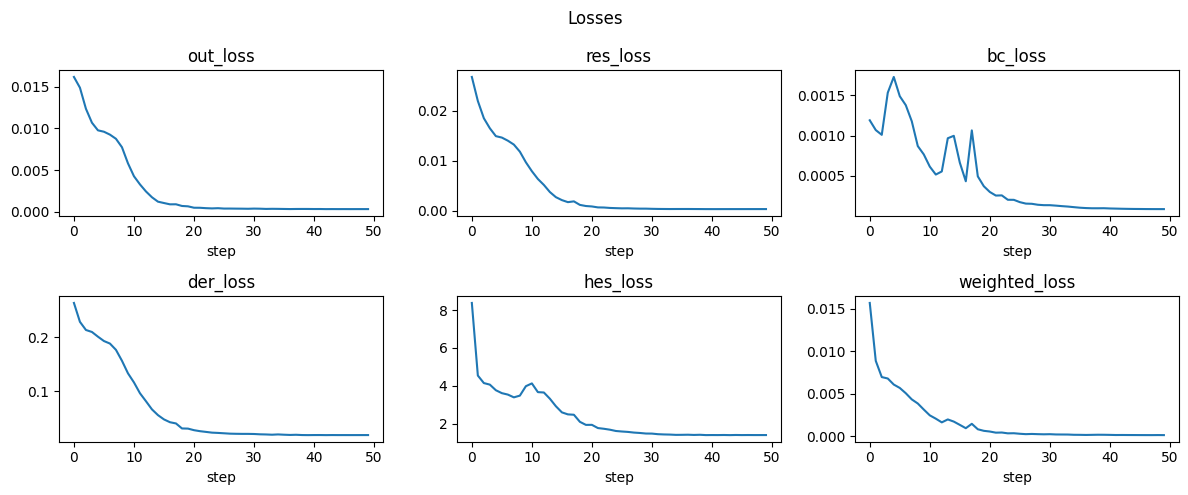


=============== Checkpoint ===============
PDE: Allen-Cahn
PDE parameters in input: ['xi1', 'xi2']
Time in input: False
Space in input: True
Fourier features: 10
|Input units|: 4
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: Norm1
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 0.823413074016571
	IC: 1.0
	RES: 0.17658692598342896
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
-------------------------------------

In [ ]:
models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models2"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train"],
    subkeys=["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "weighted_loss"],
    figsize=(12, 5),
    legend=False,
    title="Losses",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/losses.png"
)

#plot_model_stats(
#    data=f"{models_dir}/trial0",
#    keys=["train"],
#    subkeys=["out_loss"]
#)
print_model_info(f"{models_dir}/trial0")

#models_dict = {"trial0": load_stats(f"{models_dir}/trial0")}
#plot_loss_comp(
#    stats_dict=models_dict,
#    phase="train",
#    loss_prefix="out",
#    save=True,
#    dst_file=f"{models_dir}/plots/loss_comp.png"
#)

Last res_loss: 0.0003515664429869503
Last grad norm: 0.0010097683407366276


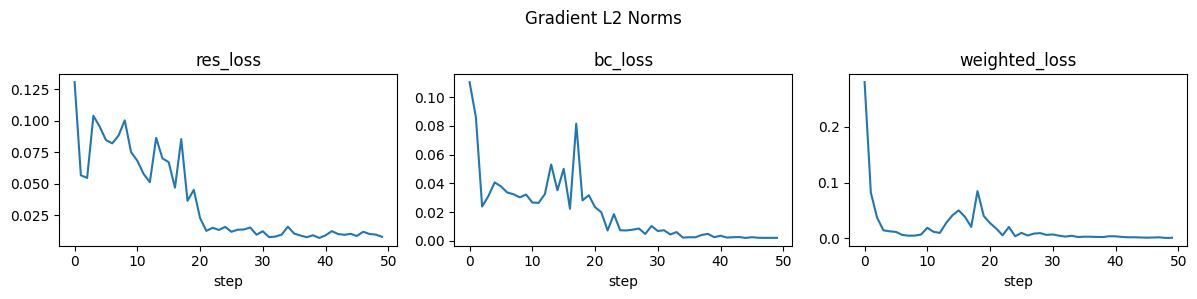

Last value weights res_loss: 0.17658692598342896
Last value weights bc_loss: 0.823413074016571


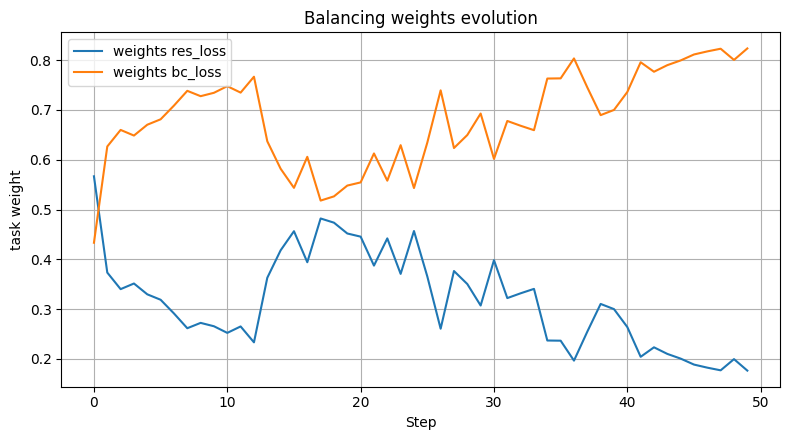

Last value conflicts bc_loss: -0.8032084107398987


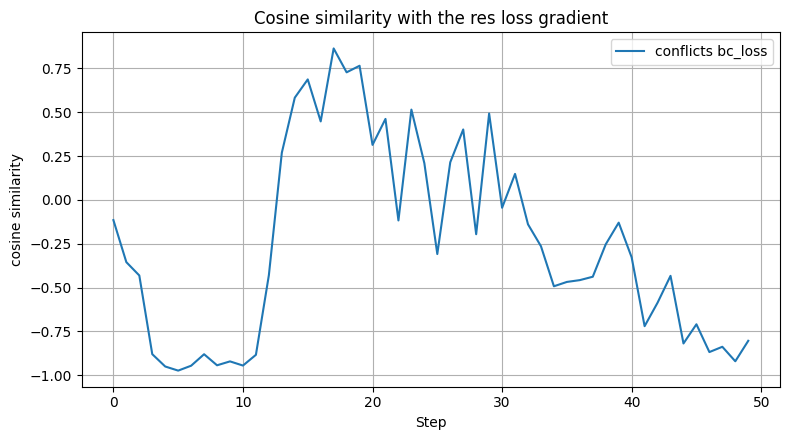

In [ ]:
start, stop = 180, 10000
loss = "res"

loss_key = f"{loss}_loss"

models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models2"
models_dict = {"trial0": load_stats(f"{models_dir}/trial0")}


print(f"Last res_loss: {models_dict['trial0']['train']['res_loss'][-1]}")
print(f"Last grad norm: {models_dict['trial0']['train_loss_grad_norm'][-1][0]}")

#models_dict["trial0"]["train"][loss_key] = models_dict["trial0"]["train"][loss_key][start:stop]
#models_dict["trial0"]["train"]["step_list"] = models_dict["trial0"]["train"]["step_list"][start:stop]
#
#models_dict["trial0"]["train_loss"] = models_dict["trial0"]["train_loss"][start:stop]
#models_dict["trial0"]["train_loss_grad_norm"] = models_dict["trial0"]["train_loss_grad_norm"][start:stop]

#plot_loss_comp(
#    stats_dict=models_dict,
#    phase="train",
#    loss_prefix=loss,
#    figsize=(4, 2.5)
#)
#plot_loss_comp(
#    stats_dict=models_dict,
#    phase="train_loss",
#    figsize=(4, 2.5)
#)
#plot_loss_comp(
#    stats_dict=models_dict,
#    phase="train_loss_grad_norm",
#    figsize=(8, 4.5),
#    save=True,
#    dst_file=f"{models_dir}/plots/loss_grad_norm.png"
#)
plot_model_stats_grid(
        data=f"{models_dir}/trial0",
        keys=["grad_norms"],
        subkeys=["res_loss", "bc_loss", "weighted_loss"],
        figsize=(12, 3),
        legend=False,
        title="Gradient L2 Norms",
        save=SAVE_PLOTS,
        dst_file=f"{models_dir}/plots/grad_norms.png"
    )

plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["weights"],
    subkeys=["res_loss", "bc_loss"],
    ylabel="task weight",
    title="Balancing weights evolution",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/weights.png"
)
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["conflicts"],
    subkeys=["bc_loss"],
    ylabel="cosine similarity",
    title="Cosine similarity with the res loss gradient",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/conflicts.png"
)

In [ ]:
if CROSS_THE_RUBICON:
    models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models2"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)
    if PARAM_INDEX != None:
        datasets = [full_datasets[PARAM_INDEX]]
    else:
        datasets = full_datasets
    best_model = resume_model(model_path=f"{models_dir}/trial0/model.pth", device="cpu")
    
    for x_datasets, s in [(datasets, "full_dataset")]:
        os.makedirs(f"{models_dir}/plots/{s}", exist_ok=True)
        for i, ds in enumerate(x_datasets):
            labeled = compute_prediction(model=best_model, dataset=ds.datasets[0])
    
            if PARAM_INDEX is None:
                j = i
            else:
                j = PARAM_INDEX
    
            if not os.path.exists(f"{PDE}/data/plots/{s}/true_values{j}.png"):
                os.makedirs(f"{PDE}/data/plots/{s}", exist_ok=True)
                true = extract_targets(dataset=ds.datasets[0])    
                vmins, vmaxs = plot_points_grid(
                    dataset=true,
                    cmap="inferno",
                    save=True,
                    dst_file=f"{PDE}/data/plots/{s}/true_values{j}.png",
                    show=False
                )
                vmins = np.array(vmins)
                vmaxs = np.array(vmaxs)
                np.save(f"{PDE}/data/plots/{s}/vmins{j}.npy", vmins)
                np.save(f"{PDE}/data/plots/{s}/vmaxs{j}.npy", vmaxs)
            else:
                vmins = np.load(f"{PDE}/data/plots/{s}/vmins{j}.npy")
                vmaxs = np.load(f"{PDE}/data/plots/{s}/vmaxs{j}.npy")
    
            plot_points_grid(
                dataset=labeled,
                cmap="inferno",
                vmins=vmins,
                vmaxs=vmaxs,
                save=True,
                dst_file=f"{models_dir}/plots/{s}/best_model_predictions{j}.png",
                show=False
            );
    
            differences = compute_prediction_difference(model=best_model, dataset=ds.datasets[0])
            #vmins = len(differences)*[min([t.min() for t in differences.tensors[1:]])]
            #vmaxs = len(differences)*[max([t.max() for t in differences.tensors[1:]])]
            plot_points_grid(
                dataset=differences,
                #vmins=vmins,
                #vmaxs=vmaxs,
                save=True,
                dst_file=f"{models_dir}/plots/{s}/differences{j}.png",
                show=False
            );
    
        print(f"{s} predictions saved.")

full_dataset predictions saved.


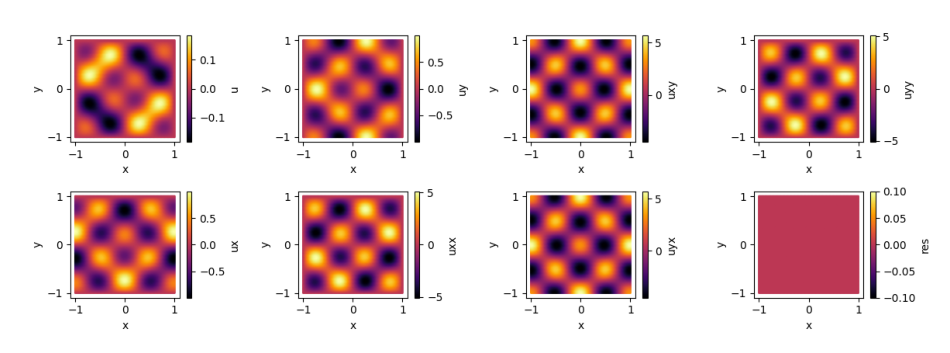

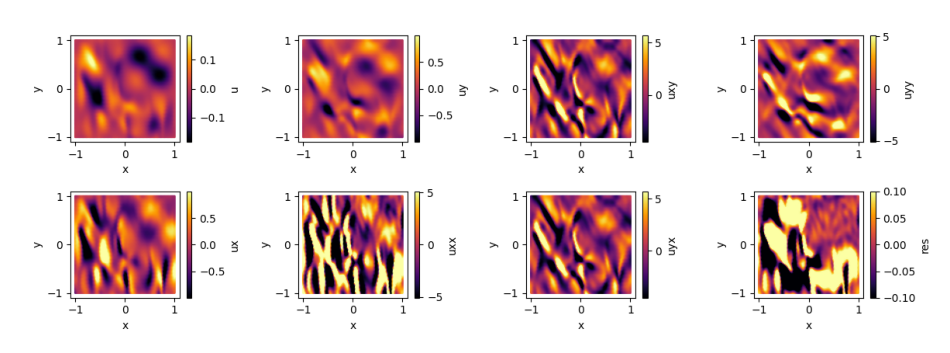

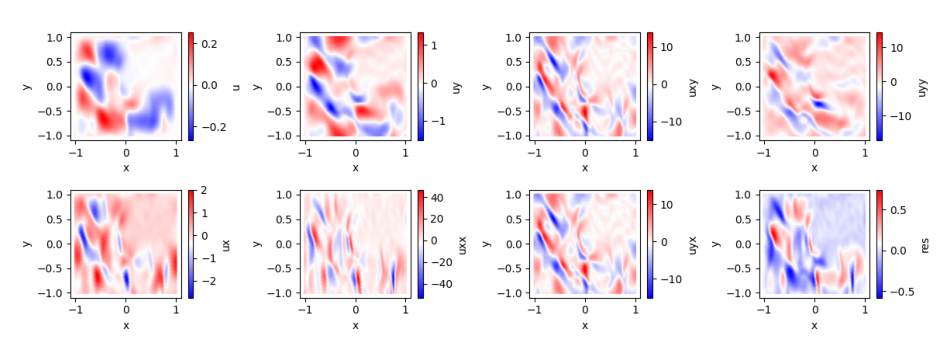

-------------------------------------------


In [ ]:
if CROSS_THE_RUBICON:
    if PARAM_INDEX is None:
        to_show = [0]
    else:
        to_show = [PARAM_INDEX]
    dataset_name = "full_dataset"
    models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models2"
    for i in to_show:
        if PARAM_INDEX is None:
            img = mpimg.imread(f"{PDE}/data/plots/{dataset_name}/true_values{i}.png")
        else:
            img = mpimg.imread(f"{PDE}/data/plots/{dataset_name}/true_values{PARAM_INDEX}.png")
        plt.figure(figsize=(12, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.show()
        for img_name in [f"best_model_predictions{i}", f"differences{i}"]:
            img = mpimg.imread(f"{models_dir}/plots/{dataset_name}/{img_name}.png")
            plt.figure(figsize=(12, 5))
            plt.imshow(img)
            plt.axis("off")
            plt.show()
        print("-------------------------------------------")

subset  metric      dev             intra_test      
--------------------------------------------------------------------------------
0       out_loss    0.0002988468    0.0003122392    
1       out_loss    0.0233505014    0.0227627605    
2       out_loss    0.0147945238    0.0143606327    
3       out_loss    0.0271279123    0.0283544008    
--------------------------------------------------------------------------------
0       der_loss    0.0195146259    0.0199526343    
1       der_loss    0.3600437045    0.3557152152    
2       der_loss    0.4015679657    0.4210044742    
3       der_loss    0.4399675429    0.4353372753    
--------------------------------------------------------------------------------
0       hes_loss    1.5087113380    1.6048474312    
1       hes_loss    32.7823791504   31.0713577271   
2       hes_loss    29.8944835663   30.2677173615   
3       hes_loss    36.5782508850   35.8043670654   
--------------------------------------------------------------------

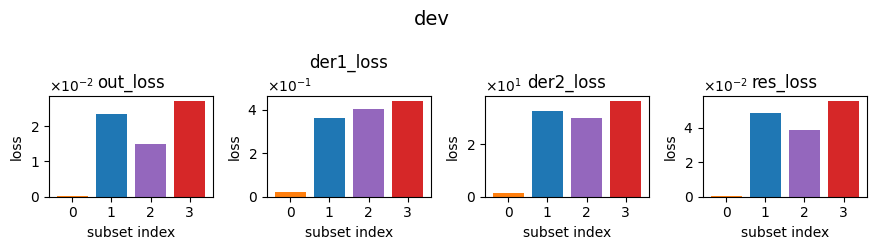

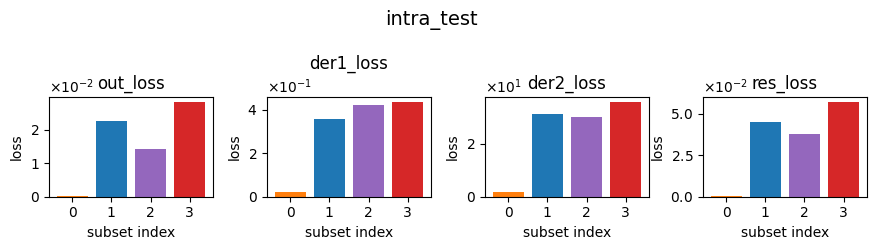

In [ ]:
if CROSS_THE_RUBICON:
    subsets = [
        {"x": [0.0, 1.0], "y": [0.0, 1.0]},
        {"x": [0.0, 1.0], "y": [-1.0, 0.0]},
        {"x": [-1.0, 0.0], "y": [-1.0, 0.0]},
        {"x": [-1.0, 0.0], "y": [0.0, 1.0]}
    ]
    
    models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models2"
    model = resume_model(model_path=f"{models_dir}/trial0/model.pth")
    
    datasets = [dev_data, intra_test_data]
    datasets_names = ["dev", "intra_test"]
    
    dst_files = ["dev_dataset", "intra_test_dataset"]
    for s in dst_files:
        os.makedirs(f"{models_dir}/plots/{s}", exist_ok=True)
    dst_files = [f"{models_dir}/plots/{s}/performance_per_subset.png" for s in dst_files]
    
    lossesss = print_model_performances(
        model=model,
        datasets=datasets,
        datasets_names=datasets_names,
        subsets=subsets
    )
    
    plot_model_performances(
        lossesss=lossesss,
        datasets_names=datasets_names,
        figsize=(9, 2.5),
        save=True,
        dst_files=dst_files
    )

In [ ]:
subsets = [
    {"x": [0.0, 1.0], "y": [0.0, 1.0]},
    {"x": [0.0, 1.0], "y": [-1.0, 0.0]},
    {"x": [-1.0, 0.0], "y": [-1.0, 0.0]},
    {"x": [-1.0, 0.0], "y": [0.0, 1.0]},
    {"x": [-1.0, 1.0], "y": [-1.0, 1.0]}
]

models_dirs = [
    f"{PDE}/FullDomainLearning/MultiTask/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2",
    f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models2"
]
models = [resume_model(model_path=f"{models_dir}/trial0/model.pth") for models_dir in models_dirs]
models_names = ["Mfull", f"M{DOM}"]

datasets = [dev_data, intra_test_data]

for i, subset in enumerate(subsets):
    datasets_names = ["dev", "intra_test"]
    if i != 4:
        datasets_names = [f"{s} - subset {i}" for s in datasets_names]
    else:
        datasets_names = [f"{s} - full domain" for s in datasets_names]

    dst_files = ["dev_dataset", "intra_test_dataset"]
    for s in dst_files:
        os.makedirs(f"{models_dirs[-1]}/plots/{s}", exist_ok=True)
    if i != 4:
        dst_files = [f"{models_dirs[-1]}/plots/{s}/full_comparison_subset{i}.png" for s in dst_files]
    else:
        dst_files = [f"{models_dirs[-1]}/plots/{s}/full_comparison_fullDomain.png" for s in dst_files]

    plot_performance_comparison(
        models=models,
        models_names=models_names,
        datasets=datasets,
        datasets_names=datasets_names,
        subset=subset,
        figsize=(11, 3),
        bar_labels=True,
        yaxis_visible=True,
        colors=["firebrick", "tab:blue"],
        save=SAVE_PLOTS,
        dst_files=dst_files,
        show=False
    )

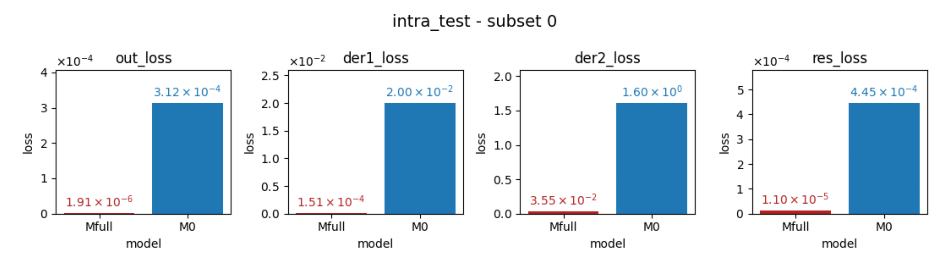

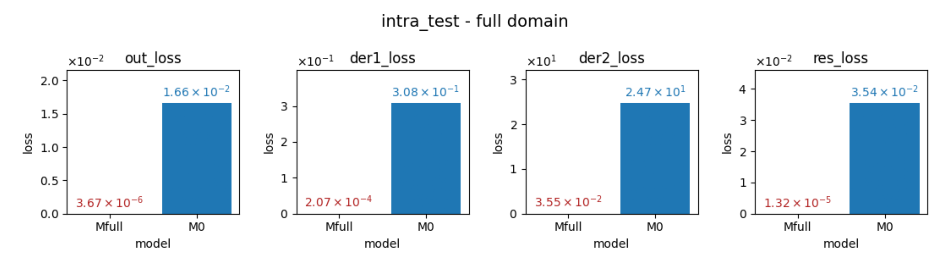

In [ ]:
subset = DOM
models_dir = f"./{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models2"

dataset_name = "intra_test_dataset"
img_file = f"{models_dir}/plots/{dataset_name}/full_comparison_subset{subset}.png"
img = mpimg.imread(img_file)
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

dataset_name = "intra_test_dataset"
img_file = f"{models_dir}/plots/{dataset_name}/full_comparison_fullDomain.png"
img = mpimg.imread(img_file)
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
if CLIP_GRAD == False:
    subsets = [{"x": [0.0, 1.0], "y": [0.0, 1.0]}]
    
    models_dirs = [
        f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_GradClip_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models2",
        f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_NoGradClip_{BD_MODE}Bd/Dom{DOM}_{N_EPOCHS}/models2"
    ]
    models = [resume_model(model_path=f"{models_dir}/trial0/model.pth") for models_dir in models_dirs]
    models_names = [f"GradClip", f"NoGradClip"]
    
    datasets = [intra_test_data]
    
    for i, subset in enumerate(subsets):
        datasets_names = ["intra_test"]
        datasets_names = [f"{s} - subset {i}" for s in datasets_names]
    
        dst_files = ["intra_test_dataset"]
        for s in dst_files:
            os.makedirs(f"{models_dirs[0]}/plots/{s}", exist_ok=True)
        dst_files = [f"{models_dirs[0]}/plots/{s}/clip_grad_or_not_subset{i}.png" for s in dst_files]
    
        plot_performance_comparison(
            models=models,
            models_names=models_names,
            datasets=datasets,
            datasets_names=datasets_names,
            subset=subset,
            figsize=(11, 3),
            bar_labels=True,
            yaxis_visible=True,
            colors=["firebrick", "tab:blue"],
            save=SAVE_PLOTS,
            dst_files=dst_files,
            show=True
        )